# 04 · Real gases and equations of state

How much CO$_2$ fits into a pipeline at 100 bar? How much hydrogen into a 700-bar tank? The ideal-gas law is
wrong by tens of percent at such conditions. Equations of state (EOS) - the virial equation at moderate
pressure, and the cubic equations of van der Waals, Redlich-Kwong, Soave and Peng-Robinson - describe real
gases and, remarkably, liquids too, from just three numbers per substance: $T_c$, $p_c$ and $\omega$.

**What you will learn**
- quantify real-gas behaviour with the compressibility factor
- use the virial and cubic equations of state
- interpret the three roots of a cubic equation
- compute gas storage densities at high pressure

**Before you start:** notebook 01; the ideal-gas law  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import components, datasets, eos
from engthermo.constants import R
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Compressibility: how far from ideal?
The compressibility factor $Z = pV/(RT)$ is 1 for an ideal gas. Reference data for CO$_2$ (from the
high-accuracy Span-Wagner equation) show what real gases do:

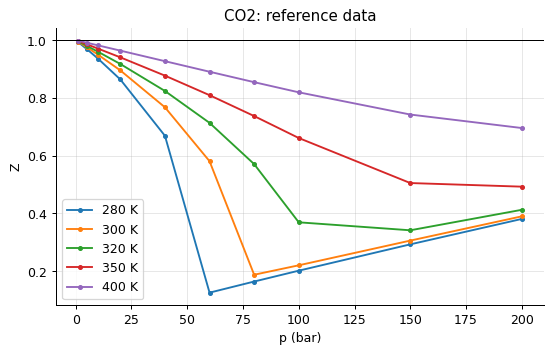

In [2]:
ref = pd.read_csv(datasets.path("real_gas_reference_densities.csv"), comment="#")
co2 = ref[ref.fluid == "CO2"]
for T, grp in co2.groupby("T_K"):
    plt.plot(grp.p_Pa / 1e5, grp.Z, "o-", ms=3, label=f"{T:.0f} K")
plt.axhline(1, color="k", lw=0.8); plt.xlabel("p (bar)"); plt.ylabel("Z"); plt.title("CO2: reference data"); plt.legend(); plt.show()

Below the critical temperature (304 K) the curves drop steeply where the gas condenses; near the critical
point $Z$ falls to about 0.3; at high temperature the gas stays closer to ideal. Attractive forces lower $Z$,
repulsion (molecular volume) raises it at very high pressure.

## The virial equation: the first correction
$Z = 1 + Bp/RT$, with the second virial coefficient $B(T)$ from the Pitzer-Abbott corresponding-states
correlation, needs only $T_c$, $p_c$ and $\omega$:

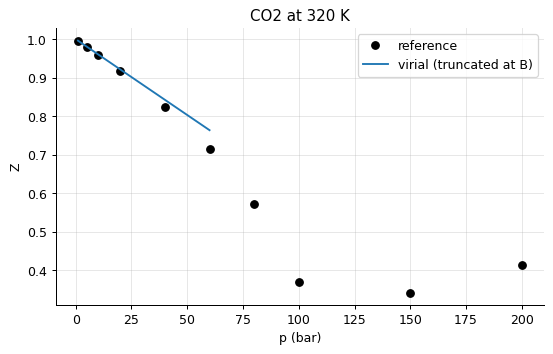

 10 bar: reference Z = 0.960, virial 0.961, ideal 1.000
 30 bar: reference Z = 0.871, virial 0.882, ideal 1.000
 60 bar: reference Z = 0.713, virial 0.763, ideal 1.000


In [3]:
T = 320.0
sel = co2[co2.T_K == T]
pp = np.linspace(1e5, 60e5, 50)
Zv = [eos.virial("CO2", T, p)["Z"] for p in pp]
plt.plot(sel.p_Pa / 1e5, sel.Z, "ko", label="reference"); plt.plot(pp / 1e5, Zv, label="virial (truncated at B)")
plt.xlabel("p (bar)"); plt.ylabel("Z"); plt.title("CO2 at 320 K"); plt.legend(); plt.show()
for p in (10e5, 30e5, 60e5):
    z_ref = float(np.interp(p, sel.p_Pa, sel.Z))
    print(f"{p/1e5:3.0f} bar: reference Z = {z_ref:.3f}, virial {eos.virial('CO2', T, p)['Z']:.3f}, ideal 1.000")

The virial equation captures the first departure from ideality and fails as the gas approaches condensation.
Its rule of thumb: adequate up to about half the critical pressure for gases (worse near $T_c$).

## Cubic equations of state
Van der Waals (1873) added two corrections to the ideal-gas law - molecular volume $b$ and attraction $a$ -
giving an equation cubic in the volume. Its successors keep the form and refine $a(T)$:

| Equation | year | temperature dependence of $a$ |
|---|---|---|
| van der Waals | 1873 | none |
| Redlich-Kwong | 1949 | $T^{-1/2}$ |
| Soave-Redlich-Kwong | 1972 | $[1 + m(\omega)(1 - \sqrt{T_r})]^2$ |
| Peng-Robinson | 1976 | as Soave, with a different volume dependence (better liquid densities) |

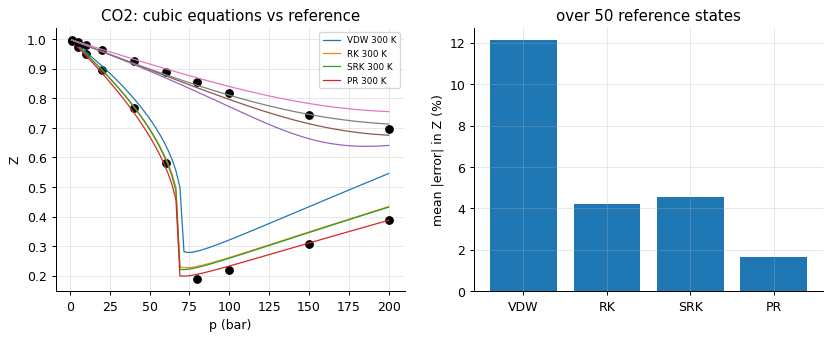

equation  mean error %  max error %
     VDW          12.1         61.1
      RK           4.2         23.4
     SRK           4.6         21.4
      PR           1.7          9.2


In [4]:
pp = np.linspace(1e5, 200e5, 80)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
for T in (300.0, 400.0):
    sel = co2[co2.T_K == T]
    a1.plot(sel.p_Pa / 1e5, sel.Z, "ko")
    for name in ("vdw", "rk", "srk", "pr"):
        a1.plot(pp / 1e5, [eos.solve(name, "CO2", T, p, "stable")["Z"] for p in pp], label=f"{name.upper()} {T:.0f} K" if T == 300 else None, lw=1)
a1.set(xlabel="p (bar)", ylabel="Z", title="CO2: cubic equations vs reference"); a1.legend(fontsize=7)
rows = []
for name in ("vdw", "rk", "srk", "pr"):
    err = [abs(eos.solve(name, "CO2", T, p, "stable")["Z"] / z - 1) for T, p, z in zip(co2.T_K, co2.p_Pa, co2.Z)]
    rows.append((name.upper(), 100 * np.mean(err), 100 * np.max(err)))
a2.bar([r[0] for r in rows], [r[1] for r in rows]); a2.set(ylabel="mean |error| in Z (%)", title="over 50 reference states")
plt.show()
print(pd.DataFrame(rows, columns=["equation", "mean error %", "max error %"]).round(1).to_string(index=False))

The refinement of $a(T)$ matters. Peng-Robinson averages under 2 % error over the whole range, with the largest
errors (up to 9 %) in the dense, liquid-like states; Redlich-Kwong and SRK average 4-5 % and err by 20 % in
the liquid; van der Waals, historic and instructive, is not accurate enough for design. Three handbook
parameters take Peng-Robinson a long way - which is why it is the workhorse of process simulators.

## Three roots: the liquid, the vapour and the one in between
Below $T_c$ the cubic can have three real roots in $V$. The smallest is the liquid, the largest the vapour, the
middle one is unstable. The p-V isotherm shows why:

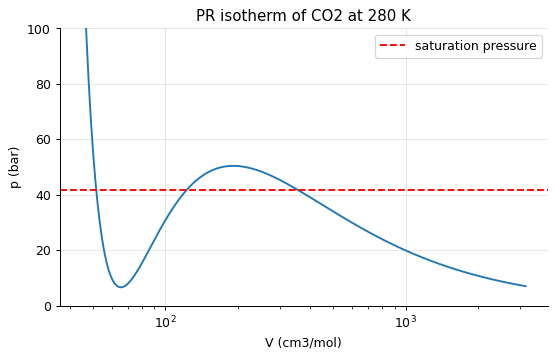

roots at the saturation pressure, Z = [0.0923 0.2188 0.6412]  -> V = [ 51.7 122.5 358.8] cm3/mol


In [5]:
T = 280.0
V = np.logspace(np.log10(4.5e-5), -2.5, 400)
p_iso = np.array([eos.pressure("pr", "CO2", T, v) for v in V])
psat = 41.6e5                                        # saturation pressure at 280 K (notebook 06 computes it)
plt.semilogx(V * 1e6, p_iso / 1e5); plt.axhline(psat / 1e5, color="r", ls="--", label="saturation pressure")
plt.ylim(0, 100); plt.xlabel("V (cm3/mol)"); plt.ylabel("p (bar)"); plt.title("PR isotherm of CO2 at 280 K"); plt.legend(); plt.show()
r = eos.solve("pr", "CO2", T, psat)
print("roots at the saturation pressure, Z =", np.round(r["roots"], 4), " -> V =", np.round(r["roots"] * R * T / psat * 1e6, 1), "cm3/mol")

The isotherm has a loop (a "van der Waals loop"): its middle part, where pressure rises with volume, is
mechanically unstable and never observed. At the saturation pressure the outer roots are the coexisting liquid
and vapour; the horizontal line replacing the loop is the phase change.

## Application: how much fits in the tank?

In [6]:
h2 = ref[ref.fluid == "hydrogen"]
sel = h2[h2.T_K == 300.0]
for p in (350e5, 700e5):
    z_ref = float(np.interp(p, sel.p_Pa, sel.Z))
    z_pr = eos.solve("pr", "H2", 300.0, p)["Z"]
    M = components.get("H2").M
    rho_ideal, rho_ref = p * M / (R * 300.0), p * M / (z_ref * R * 300.0)
    print(f"hydrogen at {p/1e5:.0f} bar, 300 K: Z = {z_ref:.3f} (PR: {z_pr:.3f}); density {rho_ref:.1f} kg/m3, ideal gas would predict "
          f"{rho_ideal:.1f} kg/m3 ({rho_ideal/rho_ref - 1:+.0%})")
sel = co2[co2.T_K == 300.0]
z = float(np.interp(100e5, sel.p_Pa, sel.Z))
print(f"CO2 at 100 bar, 300 K: Z = {z:.3f}; density {100e5 * 0.04401 / (z * R * 300):.0f} kg/m3 - a dense liquid, "
      f"{1/z:.0f} times the ideal-gas value")

hydrogen at 350 bar, 300 K: Z = 1.220 (PR: 1.163); density 23.2 kg/m3, ideal gas would predict 28.3 kg/m3 (+22%)
hydrogen at 700 bar, 300 K: Z = 1.449 (PR: 1.380); density 39.1 kg/m3, ideal gas would predict 56.6 kg/m3 (+45%)
CO2 at 100 bar, 300 K: Z = 0.220; density 802 kg/m3 - a dense liquid, 5 times the ideal-gas value


For hydrogen the deviation goes the other way: at 700 bar $Z$ is about 1.5, so a tank holds a third *less*
hydrogen than the ideal-gas law promises - a central number in the design of fuel-cell vehicles. For CO$_2$ at
100 bar, the "gas" is a liquid of about 800 kg/m$^3$: pipelines and storage for carbon capture run in this dense
phase, and their design starts with an equation of state.

## Inside the algorithm: solving the cubic for Z
For the Peng-Robinson equation, with $A = ap/(RT)^2$ and $B = bp/RT$, the compressibility factor satisfies
$Z^3 - (1 - B)Z^2 + (A - 3B^2 - 2B)Z - (AB - B^2 - B^3) = 0$. `np.roots` finds all three:

In [7]:
prm = eos.parameters("pr", "CO2", 280.0)
A_, B_ = prm["a"] * 41.6e5 / (R * 280.0) ** 2, prm["b"] * 41.6e5 / (R * 280.0)
roots = np.roots([1, -(1 - B_), A_ - 3 * B_**2 - 2 * B_, -(A_ * B_ - B_**2 - B_**3)])
print("by hand:", np.sort(roots.real).round(4), " library:", np.round(eos.solve("pr", "CO2", 280.0, 41.6e5)["roots"], 4))

by hand: [0.0923 0.2188 0.6412]  library: [0.0923 0.2188 0.6412]


## Exercises
1. A pipeline carries CO2 at 300 K and 100 bar. Using the Peng-Robinson equation, how many tonnes are in 10 km of 0.5 m inside diameter? How wrong is the ideal-gas estimate? Compare the PR density with the reference data.
2. Plot Z of methane at 200 K from 1 to 300 bar with the SRK and PR equations. At which pressure does Z pass through a minimum, and what does it mean physically that Z rises above 1 at very high pressure?
3. **Implement it yourself:** write the van der Waals equation from scratch ($a = 27R^2T_c^2/(64p_c)$, $b = RT_c/(8p_c)$), solve it for the molar volume of CO2 at 320 K and 50 bar with `brentq`, and compare with `eos.solve('vdw', ...)`.